We are often interested in questions that have only two possible answers: a patient either develops a disease or does not, a user either clicks a link or ignores it, a system either fails or continues to operate. Despite their simplicity, such outcomes require careful modeling because the underlying processes that generate them are rarely simple. These are essentially ‘classification’ problems.

Two of the most commonly used approaches for handling these situations are **logistic regression (logit)** and **probit regression**. Sometimes, or most of the time, they appear interchangeable. In fact, if you fit both models on the same dataset, you will usually obtain very similar predicted probabilities. This is why, in many applied workflows, the distinction between them is sometimes overlooked.


However, this similarity can be misleading. The two models are built on fundamentally different assumptions about how the data are generated. Logistic regression models the relationship through odds, while probit regression assumes the existence of an underlying latent variable that follows a normal distribution and is only observed after crossing a threshold.

## The Core Idea: Modeling Probabilities

Both logit and probit models try to answer the same question:

> ### How does a set of predictors map to the probability of an event?

Instead of modeling probability directly, they transform it into a linear form:

**Logit** uses log-odds and **Probit** uses a latent normal variable.

## Logistic Regression (Logit)

Logistic regression approaches the binary outcome problem by modeling how the **log-odds** of an event change with the predictors. Instead of working directly with probabilities (which are constrained between 0 and 1), it transforms them into a scale where a linear relationship can be established.

Rather than starting with the equation, it is more intuitive to understand the model through its shape. The logistic function maps any real-valued input into a probability, producing a smooth S-shaped curve.

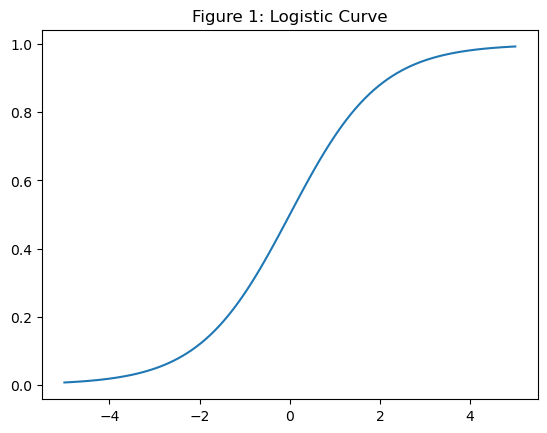

In [1]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(-5, 5, 100)
y = 1 / (1 + np.exp(-x))

plt.plot(x, y)
plt.title("Figure 1: Logistic Curve")
plt.show()

The coefficients represent changes in log-odds, which can be directly converted into odds ratios. This makes the model easy to interpret.

## Probit Regression

Probit regression is based on a slightly different way of thinking about binary outcomes. Instead of modeling the probability directly, it assumes that there is an underlying continuous (latent) variable that we do not observe. What we observe is only the final outcome , whether this hidden variable crosses a certain threshold.

For instance, in mental health studies, an individual may have an underlying liability or risk level, but we only observe a diagnosis as either present or absent. Similarly, a person may have a continuous risk score for a disease, but the recorded outcome is simply whether the disease occurs or not.

In the probit framework, this unobserved latent variable is assumed to follow a normal distribution (Example Figure 2), and the binary outcome arises from thresholding this continuous process.

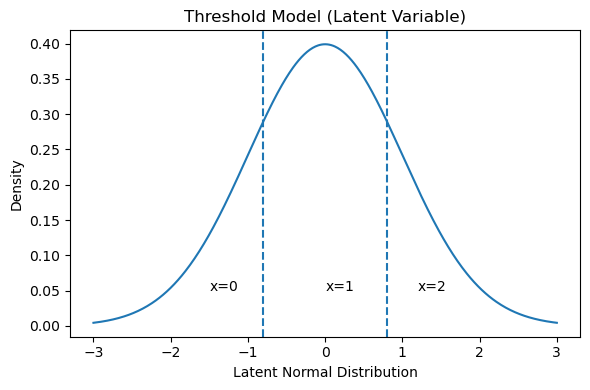

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

x = np.linspace(-3, 3, 500)
y = norm.pdf(x)

plt.figure(figsize=(6,4))
plt.plot(x, y)

# thresholds
plt.axvline(-0.8, linestyle='--')
plt.axvline(0.8, linestyle='--')

plt.text(-1.5, 0.05, "x=0")
plt.text(0, 0.05, "x=1")
plt.text(1.2, 0.05, "x=2")

plt.title("Threshold Model (Latent Variable)")
plt.xlabel("Latent Normal Distribution")
plt.ylabel("Density")

plt.tight_layout()
#plt.savefig("images/threshold_model.png", dpi=300)
plt.show()

### Interpretation

Coefficients relate to a z-score scale


Naturally fits problems where:

There is an underlying continuous process

The observed outcome is a thresholded version

## Logistic vs Normal Link

The distinction between logit and probit ultimately comes down to the link function they use:

Logit → logistic cumulative distribution function (CDF)
Probit → normal (Gaussian) cumulative distribution function (CDF)

Visually, however, these two functions are remarkably similar.







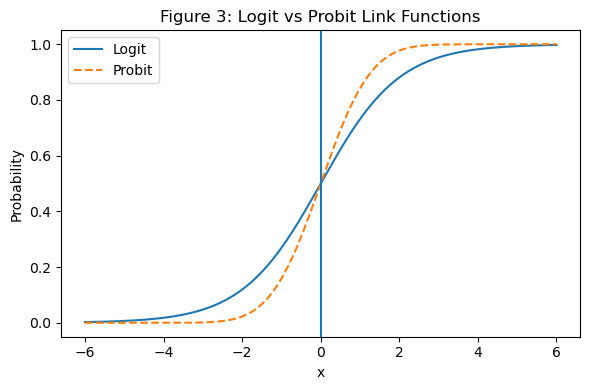

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

x = np.linspace(-6, 6, 500)

# logit
logit = 1 / (1 + np.exp(-x))

# probit
probit = norm.cdf(x)

plt.figure(figsize=(6,4))
plt.plot(x, logit, label="Logit")
plt.plot(x, probit, linestyle='--', label="Probit")

plt.axvline(0)

plt.xlabel("x")
plt.ylabel("Probability")
plt.title("Figure 3: Logit vs Probit Link Functions")
plt.legend()

plt.tight_layout()
#plt.savefig("images/logit_vs_probit.png", dpi=300)
plt.show()

In the Figure 3, the solid blue curve represents the logistic function (logit), while the dashed orange curve represents the normal CDF (probit). Both curves map input values (x-axis) to probabilities between 0 and 1 (y-axis), and both exhibit the familiar S-shaped pattern.

At the center (around (x = 0)), the two curves are almost indistinguishable. This is why, in many practical applications, logit and probit models produce nearly identical predictions.

The difference becomes more noticeable in the tails(Figure 5):

The logistic curve has slightly heavier tails, meaning probabilities change more gradually as we move toward extreme values.
The probit curve, based on the normal distribution, is steeper in the middle and flattens more quickly in the extremes.
In simple terms:

Logit spreads probability changes more evenly across the range
Probit concentrates changes more tightly around the center
This subtle difference is usually negligible for standard datasets, but it can matter when:

probabilities are very close to 0 or 1
predictors are highly skewed
or when modeling assumptions about an underlying latent normal process are important

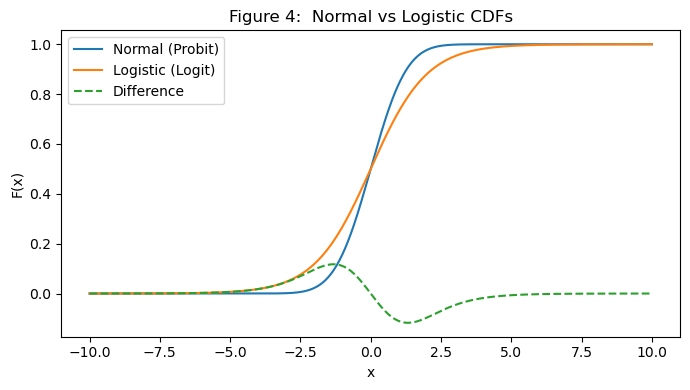

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

x = np.linspace(-10, 10, 1000)

# CDFs
normal_cdf = norm.cdf(x)
logistic_cdf = 1 / (1 + np.exp(-x))

# Difference
diff = logistic_cdf - normal_cdf

plt.figure(figsize=(7,4))

plt.plot(x, normal_cdf, label="Normal (Probit)")
plt.plot(x, logistic_cdf, label="Logistic (Logit)")
plt.plot(x, diff, linestyle='--', label="Difference")

plt.xlabel("x")
plt.ylabel("F(x)")
plt.title("Figure 4:  Normal vs Logistic CDFs")
plt.legend()

plt.tight_layout()
#plt.savefig("images/cdf_comparison.png", dpi=300)
plt.show()

## Normal vs Logistic CDFs

In Figure 4, the blue curve represents the normal CDF (used in probit), and the red curve represents the logistic CDF (used in logit). At first glance, the two curves almost overlap, especially around the center of the distribution. This explains why, in many practical datasets, both models produce nearly identical predictions.

However, the differences become more visible when you examine the curves more carefully:

Around the center (x ≈ 0), the normal curve is slightly steeper. This means probit transitions more quickly from low to high probabilities in this region.
In the tails (large positive or negative x), the logistic curve is slightly higher (on the right) and lower (on the left), reflecting its heavier tails. In practical terms, logit allows probabilities to move more gradually toward 0 and 1.
The dashed line in the figure highlights the difference between the two functions. Notice that:

The difference is very small across most of the range
It peaks slightly away from the center
It quickly diminishes toward the extremes
The two models are not fundamentally different in shape, they are scaled versions of each other with subtle tail behavior differences.

This is why a simple rule of thumb often works:

Logistic coefficients are approximately 1.6 times the probit coefficients

But the figure also shows why this is only an approximation. The scaling is not perfectly uniform across all values of (x), especially away from the center.

For moderate predictor values, logit and probit behave almost identically
For extreme values or rare events, their differences become more noticeable
If your interpretation depends on a latent normal structure, probit aligns more naturally
If you prefer odds-based interpretation, logit is more convenient

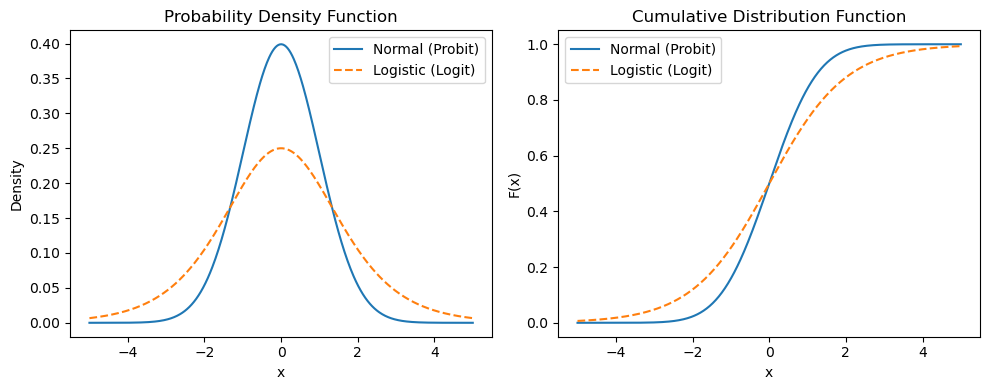

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

x = np.linspace(-5, 5, 500)

# PDFs
normal_pdf = norm.pdf(x)
logistic_pdf = np.exp(-x) / (1 + np.exp(-x))**2

# CDFs
normal_cdf = norm.cdf(x)
logistic_cdf = 1 / (1 + np.exp(-x))

fig, axes = plt.subplots(1, 2, figsize=(10,4))

# --- PDF ---
axes[0].plot(x, normal_pdf, label="Normal (Probit)")
axes[0].plot(x, logistic_pdf, linestyle='--', label="Logistic (Logit)")
axes[0].set_title("Probability Density Function")
axes[0].set_xlabel("x")
axes[0].set_ylabel("Density")
axes[0].legend()

# --- CDF ---
axes[1].plot(x, normal_cdf, label="Normal (Probit)")
axes[1].plot(x, logistic_cdf, linestyle='--', label="Logistic (Logit)")
axes[1].set_title("Cumulative Distribution Function")
axes[1].set_xlabel("x")
axes[1].set_ylabel("F(x)")
axes[1].legend()

plt.tight_layout()
#plt.savefig("images/pdf_cdf_comparison.png", dpi=300)
plt.show()

Logistic has slightly heavier tails and probit is tighter (normal-based).

In most datasets → results are almost identical. But differences emerge in extreme probabilities, non-Gaussian predictors, and latent trait modeling.



## Simulation: Logit vs Probit in Practice

Let’s simulate a dataset and fit both models.

### Generate synthetic data

In [6]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 1000
X = np.random.normal(0, 1, n)
# True latent model (probit-style)
latent = 1.5 * X + np.random.normal(0, 1, n)
y = (latent > 0).astype(int)
df = pd.DataFrame({'X': X, 'y': y})

### Fit Logit and Probit models

In [7]:
import statsmodels.api as sm

X_design = sm.add_constant(df['X'])
logit_model = sm.Logit(df['y'], X_design).fit(disp=0)
probit_model = sm.Probit(df['y'], X_design).fit(disp=0)
print("Logit coefficients:\n", logit_model.params)
print("\nProbit coefficients:\n", probit_model.params)

Logit coefficients:
 const    0.092656
X        2.518358
dtype: float64

Probit coefficients:
 const    0.059112
X        1.458320
dtype: float64


## NOTE

Coefficients differ in scale

But predictions are very similar


### Compare predicted probabilities

In [8]:
x_vals = np.linspace(-3, 3, 100)
X_plot = sm.add_constant(x_vals)

logit_pred = logit_model.predict(X_plot)
probit_pred = probit_model.predict(X_plot)


## Visualization

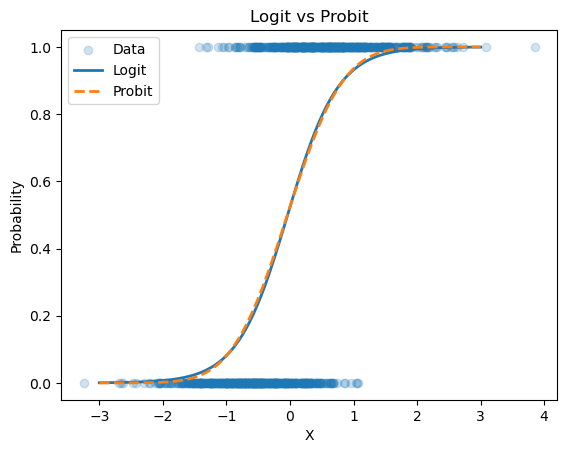

In [9]:
import matplotlib.pyplot as plt

plt.scatter(df['X'], df['y'], alpha=0.2, label="Data")
plt.plot(x_vals, logit_pred, label="Logit", linewidth=2)
plt.plot(x_vals, probit_pred, label="Probit", linestyle='--', linewidth=2)
plt.xlabel("X")
plt.ylabel("Probability")
plt.legend()
plt.title("Logit vs Probit")
plt.show()

## Note:

Nearly overlapping curves

Small differences at extremes



## When Should You Use Logit?

Logistic regression is often the natural starting point for binary outcome modeling. It is particularly useful when your goal is clear interpretation. The coefficients can be translated into odds ratios, which are widely understood and easy to communicate, especially in applied settings.

Logit is commonly used in areas such as medical research, risk modeling, and general machine learning classification tasks. In many of these cases, the primary objective is to understand how predictors influence the probability of an outcome, without making strong assumptions about an underlying latent process.

In practice, logit is often treated as the default choice because of its simplicity, interpretability, and broad applicability.

## When Should You Use Probit?
    
Probit becomes more appropriate when your problem naturally suggests the presence of an underlying continuous process that is not directly observed. Instead of modeling probabilities through odds, it assumes that the observed binary outcome arises from a latent variable crossing a threshold, with that latent variable following a normal distribution.

This perspective is especially relevant in fields such as statistical genetics, econometrics, and psychometrics, where the concept of an unobserved trait, such as liability, ability, or risk , is central to the analysis.

Probit is particularly useful when you care about interpretation on a latent scale, or when your modeling framework already assumes normality. It can also behave more consistently in settings where predictors are highly skewed or when the outcome is rare.

In certain applications, particularly in fields like statistical genetics, you may come across the statement:

“Probit behaves better on the liability scale.”

This idea comes from how the probit model is constructed. Because it is based on the normal distribution, it aligns naturally with frameworks that assume an underlying continuous latent trait, such as disease liability. This makes it a more coherent choice when working with concepts like heritability or liability threshold models, where the entire interpretation is built around a normally distributed hidden variable.

Logit, on the other hand, models the outcome through odds rather than a latent continuous process. While this works well for prediction and interpretation in many settings, it can become less stable when you try to map results onto a latent scale, especially in situations with rare outcomes or strong class imbalance. In such cases, the transformation from observed probabilities to an underlying scale can be more sensitive and less consistent.

In short, probit tends to behave more smoothly when your modeling framework explicitly assumes a normal latent structure, whereas logit is more flexible but less naturally aligned with that interpretation.




### Example case : When Logit Becomes Less Stable but Probit Remains Well Behaved

We already discussed that differences between logit and probit become clearer when the predictor is non-Gaussian, for example:

a family history indicator: 0 or 1
a polygenic score with outliers
a highly skewed biomarker
a rare exposure variable
Let’s simulate this.

### Create a Non-Gaussian Predictor







In [10]:
import numpy as np
import pandas as pd


np.random.seed(42)
n = 5000
# Non-Gaussian predictor:
# Most people have low values, a few have very high values
X = np.random.exponential(scale=1.0, size=n)
# Standardize
X = (X - X.mean()) / X.std()

Here, X is not normally distributed. It is right-skewed. This mimics many real situations where most individuals have low exposure, but a small group has very high exposure.

### Generate a Binary Outcome from a Latent Liability Model


In [11]:
latent_liability = 1.2 * X + np.random.normal(0, 1, n)


# Rare outcome: only people above a high threshold become cases
threshold = np.percentile(latent_liability, 90)
y = (latent_liability > threshold).astype(int)
df = pd.DataFrame({"X": X, "y": y})

This creates a binary outcome from an underlying continuous liability. Only the top 10% cross the threshold and become cases.

This setup is closer to many disease-risk problems than a balanced 50/50 classification task.

### Fit Logit and Probit


In [12]:
import statsmodels.api as sm


X_design = sm.add_constant(df["X"])
logit_model = sm.Logit(df["y"], X_design).fit(disp=0)
probit_model = sm.Probit(df["y"], X_design).fit(disp=0)
print("Logit coefficients")
print(logit_model.params)
print("\nProbit coefficients")
print(probit_model.params)

Logit coefficients
const   -3.537571
X        2.098174
dtype: float64

Probit coefficients
const   -1.916994
X        1.121279
dtype: float64


The coefficients will not be directly comparable because logit and probit use different scales.

A rough rule is:

logit coefficient ≈ 1.6 × probit coefficient

But this is only an approximation. It works best when the data are well behaved.

### Compare Predicted Probabilities


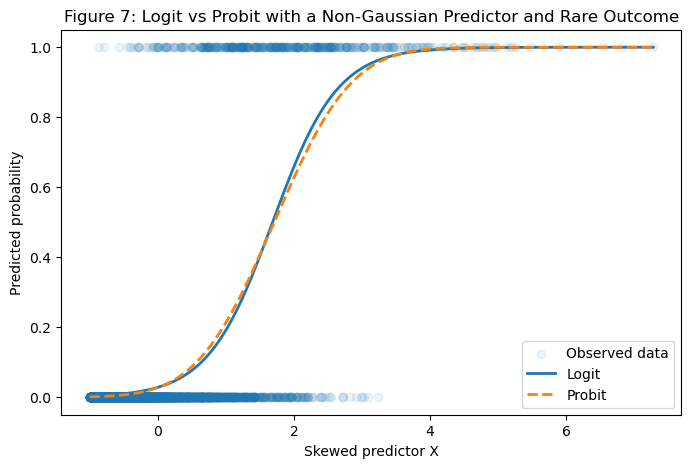

In [13]:
import matplotlib.pyplot as plt


x_vals = np.linspace(df["X"].min(), df["X"].max(), 300)
X_plot = sm.add_constant(x_vals)
logit_pred = logit_model.predict(X_plot)
probit_pred = probit_model.predict(X_plot)
plt.figure(figsize=(8, 5))
plt.scatter(df["X"], df["y"], alpha=0.08, label="Observed data")
plt.plot(x_vals, logit_pred, label="Logit", linewidth=2)
plt.plot(x_vals, probit_pred, label="Probit", linestyle="--", linewidth=2)
plt.xlabel("Skewed predictor X")
plt.ylabel("Predicted probability")
plt.title("Figure 7: Logit vs Probit with a Non-Gaussian Predictor and Rare Outcome")
plt.legend()
plt.show()

You can see (Figure 7 ) that both models still follow the same broad pattern. But they can diverge at the extremes, especially for very high predictor values.


This is where instability begins to matter.

### Repeat the Simulation Many Times

One simulation is not enough. To see stability, we repeat the analysis many times and compare the variability of the estimated coefficients.



In [14]:
from scipy.stats import skew
import warnings

warnings.filterwarnings("ignore")
n_sim = 300
results = []
for i in range(n_sim):
    X = np.random.exponential(scale=1.0, size=n)
    X = (X - X.mean()) / X.std()
    latent_liability = 1.2 * X + np.random.normal(0, 1, n)
    threshold = np.percentile(latent_liability, 90)
    y = (latent_liability > threshold).astype(int)
    df_sim = pd.DataFrame({"X": X, "y": y})
    X_design = sm.add_constant(df_sim["X"])
    try:
        logit_fit = sm.Logit(df_sim["y"], X_design).fit(disp=0)
        probit_fit = sm.Probit(df_sim["y"], X_design).fit(disp=0)
        results.append({
            "logit_beta": logit_fit.params["X"],
            "probit_beta": probit_fit.params["X"],
            "x_skewness": skew(X),
            "case_fraction": y.mean()
        })
    except Exception:
        continue
results_df = pd.DataFrame(results)
print(results_df.describe())

       logit_beta  probit_beta  x_skewness  case_fraction
count  300.000000   300.000000  300.000000   3.000000e+02
mean     2.266965     1.201405    1.985715   1.000000e-01
std      0.082265     0.042510    0.119162   5.143361e-16
min      2.008005     1.071029    1.683856   1.000000e-01
25%      2.209380     1.171932    1.902065   1.000000e-01
50%      2.265980     1.202383    1.982897   1.000000e-01
75%      2.323948     1.230140    2.050532   1.000000e-01
max      2.504311     1.322372    2.554531   1.000000e-01


Now visualize the coefficient variability (Figure 8 ).


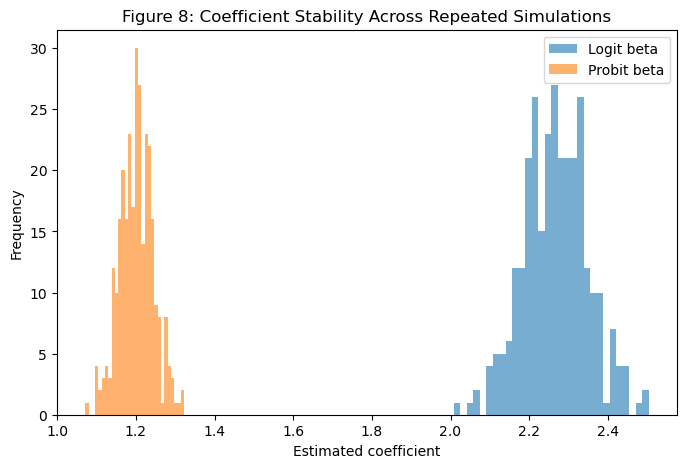

In [15]:
plt.figure(figsize=(8, 5))

plt.hist(results_df["logit_beta"], bins=30, alpha=0.6, label="Logit beta")
plt.hist(results_df["probit_beta"], bins=30, alpha=0.6, label="Probit beta")
plt.xlabel("Estimated coefficient")
plt.ylabel("Frequency")
plt.title("Figure 8: Coefficient Stability Across Repeated Simulations")
plt.legend()
plt.show()

Because the two models are on different scales, we should also rescale the probit coefficient (Figure 9).

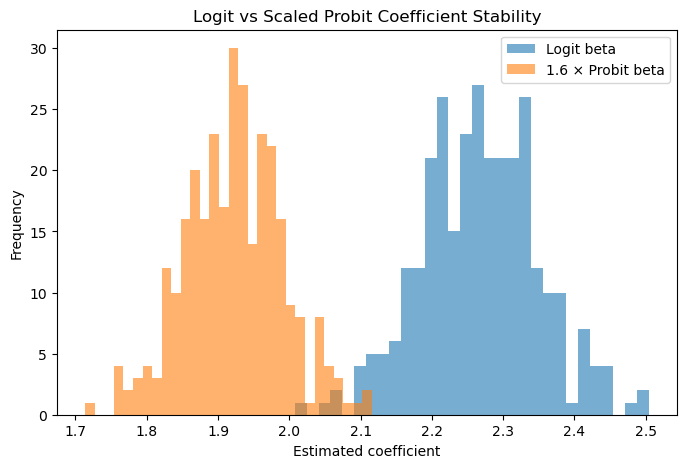

In [16]:
results_df["probit_beta_scaled"] = 1.6 * results_df["probit_beta"]


plt.figure(figsize=(8, 5))
plt.hist(results_df["logit_beta"], bins=30, alpha=0.6, label="Logit beta")
plt.hist(results_df["probit_beta_scaled"], bins=30, alpha=0.6, label="1.6 × Probit beta")
plt.xlabel("Estimated coefficient")
plt.ylabel("Frequency")
plt.title("Logit vs Scaled Probit Coefficient Stability")
plt.legend()
plt.show()

In well-behaved data, logit and probit are almost interchangeable.

But when the predictor is skewed and the outcome is rare:

logit coefficients may show more variability
odds-based interpretation can become sensitive to extreme observations
probit may remain more aligned with the latent liability-generating process
probit predictions may behave more smoothly near the threshold region
This does not mean logit is “bad.” It means that logit answers a slightly different question.

Logit asks:

How does the predictor change the odds of being a case?

Probit asks:

How does the predictor shift the underlying latent liability?

For ordinary classification, the logit question is often enough. For liability-scale thinking, especially in genetics, the probit question is often more natural.

### Visualize the Latent Liability Threshold

This plot (Figure 10) helps connect the simulation to the idea of disease liability.

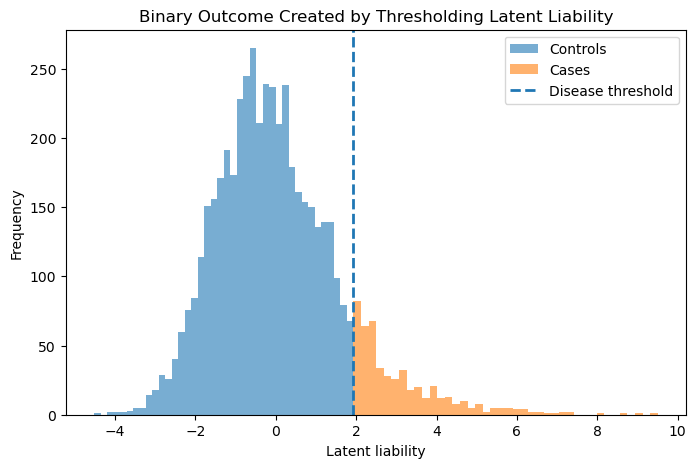

In [17]:
plt.figure(figsize=(8, 5))

plt.hist(latent_liability[y == 0], bins=40, alpha=0.6, label="Controls")
plt.hist(latent_liability[y == 1], bins=40, alpha=0.6, label="Cases")
plt.axvline(threshold, linestyle="--", linewidth=2, label="Disease threshold")
plt.xlabel("Latent liability")
plt.ylabel("Frequency")
plt.title("Binary Outcome Created by Thresholding Latent Liability")
plt.legend()
plt.show()

The disease outcome is binary, but the process underneath is continuous. This is why probit is attractive in liability-threshold settings.
